In [1]:
import pandas as pd

In [12]:
cadastrados = pd.read_csv("https://github.com/alura-tech/alura-tech-pos-data-science-credit-scoring-streamlit/blob/main/dados/clientes_cadastrados.csv?raw=True");

In [24]:
cadastrados.head(3)

,ID_Cliente,Genero,Tem_carro,Tem_casa_propria,Qtd_filhos,Rendimento_anual,Categoria_de_renda,Grau_escolaridade,Estado_civil,Moradia,Idade,Anos_empregado,Tem_celular,Tem_telefone_trabalho,Tem_telefone_fixo,Tem_email,Ocupacao,Tamanho_familia
0,5008804,M,Y,Y,0,427500.0,Empregado,Ensino superior,União-estável,Apartamento alugado,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Empregado,Ensino superior,União-estável,Apartamento alugado,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Empregado,Ensino médio,Casado,Casa/apartamento próprio,-21474,-1134,1,0,0,0,Segurança,2.0


In [14]:
cadastrados.shape

(438557, 18)

In [15]:
cadastrados['ID_Cliente'].value_counts()

ID_Cliente
7702516    2
7602432    2
7836971    2
7213374    2
7052783    2
          ..
6840104    1
6840222    1
6841878    1
6842765    1
5008808    1
Name: count, Length: 438510, dtype: int64

In [18]:
id_repetidos = cadastrados[cadastrados["ID_Cliente"].duplicated(keep=False)]

In [19]:
df_cadstrados_limpo = cadastrados.drop(id_repetidos.index)

In [22]:
df_cadstrados_limpo['ID_Cliente'].value_counts()

ID_Cliente
6842885    1
5008804    1
5008805    1
5008806    1
5008808    1
          ..
5008825    1
5008824    1
5008823    1
5008822    1
5008821    1
Name: count, Length: 438463, dtype: int64

In [23]:
df_cadstrados_limpo.isnull().sum()

ID_Cliente                    0
Genero                        0
Tem_carro                     0
Tem_casa_propria              0
Qtd_filhos                    0
Rendimento_anual              0
Categoria_de_renda            0
Grau_escolaridade             0
Estado_civil                  0
Moradia                       0
Idade                         0
Anos_empregado                0
Tem_celular                   0
Tem_telefone_trabalho         0
Tem_telefone_fixo             0
Tem_email                     0
Ocupacao                 134177
Tamanho_familia               0
dtype: int64

In [26]:
df_cadstrados_limpo['Ocupacao'].unique()

array([nan, 'Segurança', 'Vendas', 'Contabilidade', 'Construção Civil',
       'Gerência', 'Motorista', 'Equipe principal', 'Alta tecnologia',
       'Limpeza', 'Serviço privado', 'Cozinha', 'Baixa qualificação',
       'Medicina', 'Secretariado', 'Garçom', 'RH', 'Corretor imobiliário',
       'TI'], dtype=object)

In [27]:
df_cadstrados_limpo['Ocupacao'].fillna(value="Outro", inplace= True)

In [29]:
df_cadstrados_limpo.isnull().sum()

ID_Cliente               0
Genero                   0
Tem_carro                0
Tem_casa_propria         0
Qtd_filhos               0
Rendimento_anual         0
Categoria_de_renda       0
Grau_escolaridade        0
Estado_civil             0
Moradia                  0
Idade                    0
Anos_empregado           0
Tem_celular              0
Tem_telefone_trabalho    0
Tem_telefone_fixo        0
Tem_email                0
Ocupacao                 0
Tamanho_familia          0
dtype: int64

In [30]:
df_cadstrados_limpo.nunique()

ID_Cliente               438463
Genero                        2
Tem_carro                     2
Tem_casa_propria              2
Qtd_filhos                   12
Rendimento_anual            866
Categoria_de_renda            5
Grau_escolaridade             5
Estado_civil                  5
Moradia                       6
Idade                     16379
Anos_empregado             9406
Tem_celular                   1
Tem_telefone_trabalho         2
Tem_telefone_fixo             2
Tem_email                     2
Ocupacao                     19
Tamanho_familia              13
dtype: int64

In [31]:
df_cadstrados_limpo.drop('Genero', axis=1,inplace=True)

In [32]:
df_cadstrados_limpo.drop('Tem_celular', axis=1,inplace=True)

In [33]:
df_cadstrados_limpo['Tem_carro'].unique()

array(['Y', 'N'], dtype=object)

In [34]:
df_cadstrados_limpo['Tem_casa_propria'].unique()

array(['Y', 'N'], dtype=object)

In [35]:
df_cadstrados_limpo['Tem_telefone_trabalho'].unique()

array([1, 0])

In [36]:
df_cadstrados_limpo['Tem_telefone_fixo'].unique()

array([0, 1])

In [38]:
df_cadstrados_limpo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 438463 entries, 0 to 438556
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID_Cliente             438463 non-null  int64  
 1   Tem_carro              438463 non-null  object 
 2   Tem_casa_propria       438463 non-null  object 
 3   Qtd_filhos             438463 non-null  int64  
 4   Rendimento_anual       438463 non-null  float64
 5   Categoria_de_renda     438463 non-null  object 
 6   Grau_escolaridade      438463 non-null  object 
 7   Estado_civil           438463 non-null  object 
 8   Moradia                438463 non-null  object 
 9   Idade                  438463 non-null  int64  
 10  Anos_empregado         438463 non-null  int64  
 11  Tem_telefone_trabalho  438463 non-null  int64  
 12  Tem_telefone_fixo      438463 non-null  int64  
 13  Tem_email              438463 non-null  int64  
 14  Ocupacao               438463 non-null  o

In [39]:
df_cadstrados_limpo['Tem_carro'] = df_cadstrados_limpo['Tem_carro'].replace(['Y','N'],[1,0])

C:\Users\Lucas Lira\AppData\Local\Temp\ipykernel_13756\3874799644.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cadstrados_limpo['Tem_carro'] = df_cadstrados_limpo['Tem_carro'].replace(['Y','N'],[1,0])


In [40]:
df_cadstrados_limpo['Tem_casa_propria'] = df_cadstrados_limpo['Tem_casa_propria'].replace(['Y','N'],[1,0])

C:\Users\Lucas Lira\AppData\Local\Temp\ipykernel_13756\406939798.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cadstrados_limpo['Tem_casa_propria'] = df_cadstrados_limpo['Tem_casa_propria'].replace(['Y','N'],[1,0])


In [41]:
df_cadstrados_limpo['Tem_carro'].unique()

array([1, 0])

In [42]:
df_cadstrados_limpo['Tem_casa_propria'].unique()

array([1, 0])

In [43]:
df_cadstrados_limpo.head(3)

,ID_Cliente,Tem_carro,Tem_casa_propria,Qtd_filhos,Rendimento_anual,Categoria_de_renda,Grau_escolaridade,Estado_civil,Moradia,Idade,Anos_empregado,Tem_telefone_trabalho,Tem_telefone_fixo,Tem_email,Ocupacao,Tamanho_familia
0,5008804,1,1,0,427500.0,Empregado,Ensino superior,União-estável,Apartamento alugado,-12005,-4542,1,0,0,Outro,2.0
1,5008805,1,1,0,427500.0,Empregado,Ensino superior,União-estável,Apartamento alugado,-12005,-4542,1,0,0,Outro,2.0
2,5008806,1,1,0,112500.0,Empregado,Ensino médio,Casado,Casa/apartamento próprio,-21474,-1134,0,0,0,Segurança,2.0


In [44]:
df_cadstrados_limpo['Idade'] = -df_cadstrados_limpo['Idade']/365.2425

In [45]:
df_cadstrados_limpo['Anos_empregado'] = -df_cadstrados_limpo['Anos_empregado']/365.2425

In [46]:
df_cadstrados_limpo.head(3)

,ID_Cliente,Tem_carro,Tem_casa_propria,Qtd_filhos,Rendimento_anual,Categoria_de_renda,Grau_escolaridade,Estado_civil,Moradia,Idade,Anos_empregado,Tem_telefone_trabalho,Tem_telefone_fixo,Tem_email,Ocupacao,Tamanho_familia
0,5008804,1,1,0,427500.0,Empregado,Ensino superior,União-estável,Apartamento alugado,32.868574,12.435574,1,0,0,Outro,2.0
1,5008805,1,1,0,427500.0,Empregado,Ensino superior,União-estável,Apartamento alugado,32.868574,12.435574,1,0,0,Outro,2.0
2,5008806,1,1,0,112500.0,Empregado,Ensino médio,Casado,Casa/apartamento próprio,58.793815,3.104787,0,0,0,Segurança,2.0


In [47]:
df_cadstrados_limpo['Anos_empregado'].value_counts()

Anos_empregado
-1000.001369    75314
 0.596864         262
 4.594208         251
 0.681739         241
 2.677673         240
                ...  
 19.488422          1
 18.133158          1
 28.671362          1
 21.837546          1
 37.402548          1
Name: count, Length: 9406, dtype: int64

In [50]:
df_cadstrados_limpo.loc[df_cadstrados_limpo['Anos_empregado'] < 0, 'Anos_empregado'] = 0

In [51]:
df_cadstrados_limpo['Anos_empregado'].value_counts()

Anos_empregado
0.000000     75314
0.596864       262
4.594208       251
0.681739       241
2.677673       240
             ...  
19.488422        1
18.133158        1
28.671362        1
21.837546        1
37.402548        1
Name: count, Length: 9406, dtype: int64

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

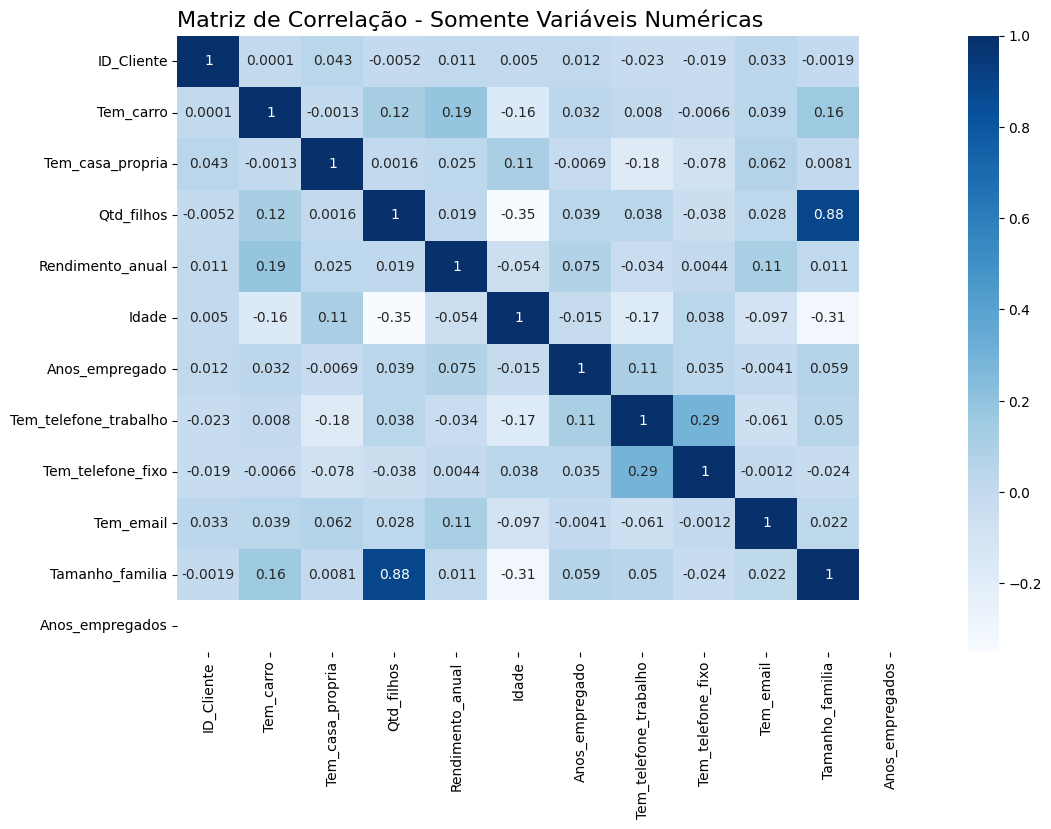

In [56]:
corr = df_cadstrados_limpo.select_dtypes(include=['number']).corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='Blues', annot=True)
plt.title('Matriz de Correlação - Somente Variáveis Numéricas', fontsize=16, loc='left')
plt.show()

In [57]:
df_cadstrados_limpo.drop(['Qtd_filhos'], axis= 1, inplace=True)

In [61]:
df_cadstrados_limpo = df_cadstrados_limpo[['ID_Cliente', 'Tem_carro','Tem_casa_propria','Tem_telefone_trabalho',
                                           'Tem_telefone_fixo','Tem_email','Tamanho_familia','Rendimento_anual',
                                           'Idade','Anos_empregado','Categoria_de_renda','Grau_escolaridade',
                                           'Estado_civil','Moradia', 'Ocupacao']]

In [62]:
df_cadstrados_limpo.head()

,ID_Cliente,Tem_carro,Tem_casa_propria,Tem_telefone_trabalho,Tem_telefone_fixo,Tem_email,Tamanho_familia,Rendimento_anual,Idade,Anos_empregado,Categoria_de_renda,Grau_escolaridade,Estado_civil,Moradia,Ocupacao
0,5008804,1,1,1,0,0,2.0,427500.0,32.868574,12.435574,Empregado,Ensino superior,União-estável,Apartamento alugado,Outro
1,5008805,1,1,1,0,0,2.0,427500.0,32.868574,12.435574,Empregado,Ensino superior,União-estável,Apartamento alugado,Outro
2,5008806,1,1,0,0,0,2.0,112500.0,58.793815,3.104787,Empregado,Ensino médio,Casado,Casa/apartamento próprio,Segurança
3,5008808,0,1,0,1,1,1.0,270000.0,52.321403,8.353354,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,Vendas
4,5008809,0,1,0,1,1,1.0,270000.0,52.321403,8.353354,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,Vendas


In [63]:
df_cadstrados_limpo['Categoria_de_renda'].value_counts(normalize=True)*100

Categoria_de_renda
Empregado              51.557144
Associado comercial    22.972520
Pensionista            17.214223
Servidor público        8.252236
Estudante               0.003877
Name: proportion, dtype: float64

In [79]:
aprovados = pd.read_csv('https://github.com/alura-tech/alura-tech-pos-data-science-credit-scoring-streamlit/blob/main/dados/clientes_aprovados.csv?raw=True')

In [68]:
aprovados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID_Cliente      1048575 non-null  int64 
 1   Mes_referencia  1048575 non-null  int64 
 2   Faixa_atraso    1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


In [69]:
aprovados.head()

,ID_Cliente,Mes_referencia,Faixa_atraso
0,5001711,0,nenhum empréstimo
1,5001711,-1,1-29 dias
2,5001711,-2,1-29 dias
3,5001711,-3,1-29 dias
4,5001712,0,pagamento realizado


In [71]:
aprovados.query('ID_Cliente == 5001711')

,ID_Cliente,Mes_referencia,Faixa_atraso
0,5001711,0,nenhum empréstimo
1,5001711,-1,1-29 dias
2,5001711,-2,1-29 dias
3,5001711,-3,1-29 dias


In [73]:
aprovados.query('ID_Cliente == 5001712')

,ID_Cliente,Mes_referencia,Faixa_atraso
4,5001712,0,pagamento realizado
5,5001712,-1,pagamento realizado
6,5001712,-2,pagamento realizado
7,5001712,-3,pagamento realizado
8,5001712,-4,pagamento realizado
9,5001712,-5,pagamento realizado
10,5001712,-6,pagamento realizado
11,5001712,-7,pagamento realizado
12,5001712,-8,pagamento realizado
13,5001712,-9,1-29 dias


In [74]:
aprovados.Faixa_atraso.value_counts()

Faixa_atraso
pagamento realizado    442031
1-29 dias              383120
nenhum empréstimo      209230
30-59 dias              11090
>150 dias                1693
60-89 dias                868
90-119 dias               320
120-149 dias              223
Name: count, dtype: int64

In [80]:
df_registros_credito_agrupados_ID = aprovados.groupby('ID_Cliente')
ser_abertura = df_registros_credito_agrupados_ID.apply(lambda x: min(x['Mes_referencia']))
ser_abertura.name = 'Abertura'
ser_abertura

C:\Users\Lucas Lira\AppData\Local\Temp\ipykernel_13756\1997392346.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ser_abertura = df_registros_credito_agrupados_ID.apply(lambda x: min(x['Mes_referencia']))


ID_Cliente
5001711    -3
5001712   -18
5001713   -21
5001714   -14
5001715   -59
           ..
5150482   -28
5150483   -17
5150484   -12
5150485    -1
5150487   -29
Name: Abertura, Length: 45985, dtype: int64

In [81]:
df_clientes_aprovados = aprovados.merge(ser_abertura, on = 'ID_Cliente')
df_clientes_aprovados.head()

,ID_Cliente,Mes_referencia,Faixa_atraso,Abertura
0,5001711,0,nenhum empréstimo,-3
1,5001711,-1,1-29 dias,-3
2,5001711,-2,1-29 dias,-3
3,5001711,-3,1-29 dias,-3
4,5001712,0,pagamento realizado,-18


In [82]:
ser_final = df_registros_credito_agrupados_ID.apply(lambda x: max(x['Mes_referencia']))
ser_final.name = 'Final'
ser_final

C:\Users\Lucas Lira\AppData\Local\Temp\ipykernel_13756\2102543870.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ser_final = df_registros_credito_agrupados_ID.apply(lambda x: max(x['Mes_referencia']))


ID_Cliente
5001711     0
5001712     0
5001713     0
5001714     0
5001715     0
           ..
5150482   -11
5150483     0
5150484     0
5150485     0
5150487     0
Name: Final, Length: 45985, dtype: int64

In [83]:
df_clientes_aprovados = df_clientes_aprovados.merge(ser_final, on = 'ID_Cliente')
df_clientes_aprovados.head()

,ID_Cliente,Mes_referencia,Faixa_atraso,Abertura,Final
0,5001711,0,nenhum empréstimo,-3,0
1,5001711,-1,1-29 dias,-3,0
2,5001711,-2,1-29 dias,-3,0
3,5001711,-3,1-29 dias,-3,0
4,5001712,0,pagamento realizado,-18,0


In [84]:
df_clientes_aprovados['Janela'] = df_clientes_aprovados['Final'] - df_clientes_aprovados['Abertura']
df_clientes_aprovados.head()

,ID_Cliente,Mes_referencia,Faixa_atraso,Abertura,Final,Janela
0,5001711,0,nenhum empréstimo,-3,0,3
1,5001711,-1,1-29 dias,-3,0,3
2,5001711,-2,1-29 dias,-3,0,3
3,5001711,-3,1-29 dias,-3,0,3
4,5001712,0,pagamento realizado,-18,0,18


In [85]:
df_clientes_aprovados['MOB'] = df_clientes_aprovados['Mes_referencia'] -  df_clientes_aprovados['Abertura']

In [86]:
df_clientes_aprovados.head()

,ID_Cliente,Mes_referencia,Faixa_atraso,Abertura,Final,Janela,MOB
0,5001711,0,nenhum empréstimo,-3,0,3,3
1,5001711,-1,1-29 dias,-3,0,3,2
2,5001711,-2,1-29 dias,-3,0,3,1
3,5001711,-3,1-29 dias,-3,0,3,0
4,5001712,0,pagamento realizado,-18,0,18,18


In [88]:
df_clientes_aprovados['Faixa_atraso'].unique()

array(['nenhum empréstimo', '1-29 dias', 'pagamento realizado',
       '30-59 dias', '60-89 dias', '90-119 dias', '120-149 dias',
       '>150 dias'], dtype=object)

In [89]:
df_clientes_aprovados_ind = {'nenhum empréstimo': 0, 'pagamento realizado': 1, '1-29 dias': 2, 
                             '30-59 dias': 3, '60-89 dias': 4, '90-119 dias': 5, '120-149 dias': 6,
                             '>150 dias': 7

}

In [90]:
df_clientes_aprovados['Ind_Faixa_atrado'] = df_clientes_aprovados['Faixa_atraso'].map(df_clientes_aprovados_ind)
df_clientes_aprovados.head()

,ID_Cliente,Mes_referencia,Faixa_atraso,Abertura,Final,Janela,MOB,Ind_Faixa_atrado
0,5001711,0,nenhum empréstimo,-3,0,3,3,0
1,5001711,-1,1-29 dias,-3,0,3,2,2
2,5001711,-2,1-29 dias,-3,0,3,1,2
3,5001711,-3,1-29 dias,-3,0,3,0,2
4,5001712,0,pagamento realizado,-18,0,18,18,1


In [91]:
df_clientes_aprovados['Mau'] = df_clientes_aprovados.apply(lambda x: 1 if x['Ind_Faixa_atrado'] > 3 else 0, axis=1)

In [97]:
df_clientes_aprovados.head()

,ID_Cliente,Mes_referencia,Faixa_atraso,Abertura,Final,Janela,MOB,Ind_Faixa_atrado,Mau
0,5001711,0,nenhum empréstimo,-3,0,3,3,0,0
1,5001711,-1,1-29 dias,-3,0,3,2,2,0
2,5001711,-2,1-29 dias,-3,0,3,1,2,0
3,5001711,-3,1-29 dias,-3,0,3,0,2,0
4,5001712,0,pagamento realizado,-18,0,18,18,1,0


In [99]:
df_registros_credito_ID = df_clientes_aprovados[['ID_Cliente', 'Abertura',
                                                 'Final','Janela']].groupby('ID_Cliente').apply(lambda x: x.iloc[0]).reset_index(drop=True)

C:\Users\Lucas Lira\AppData\Local\Temp\ipykernel_13756\333088474.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  'Final','Janela']].groupby('ID_Cliente').apply(lambda x: x.iloc[0]).reset_index(drop=True)


In [100]:
df_registros_credito_ID.head()

,ID_Cliente,Abertura,Final,Janela
0,5001711,-3,0,3
1,5001712,-18,0,18
2,5001713,-21,0,21
3,5001714,-14,0,14
4,5001715,-59,0,59


In [101]:
df_denominador = df_registros_credito_ID.groupby('Abertura').apply(lambda x: x['ID_Cliente'].count()).reset_index()
df_denominador.coluns = ['Abertura', 'Qtd_Clientes']

C:\Users\Lucas Lira\AppData\Local\Temp\ipykernel_13756\2287479417.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_denominador = df_registros_credito_ID.groupby('Abertura').apply(lambda x: x['ID_Cliente'].count()).reset_index()
C:\Users\Lucas Lira\AppData\Local\Temp\ipykernel_13756\2287479417.py:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_denominador.coluns = ['Abertura', 'Qtd_Clientes']


In [102]:
df_denominador

,Abertura,0
0,-60,415
1,-59,406
2,-58,440
3,-57,400
4,-56,470
...,...,...
56,-4,874
57,-3,919
58,-2,771
59,-1,686
